## ЯЧЕЙКИ ДЛЯ GPU!!!!

In [1]:
!python -c "import torch; print(torch.__version__); print(torch.cuda.is_available())"
!python -c "import torch; print(torch.version.cuda)"
!nvidia-smi

2.5.1+cu121
True
12.1
Wed Mar 25 14:07:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.74                 Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2050      WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   53C    P8              1W /   55W |     111MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------------

In [1]:
%pip cache purge
# здест главное смотреть вывод- возможно потребуется перезапуск (не пересоздание) среды

Files removed: 0
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip uninstall torch -y

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install torch --index-url https://download.pytorch.org/whl/cu121

^C
Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 2.4/2.4 GB ? eta 0:00:00
  Obtaining dependency information for sympy==1.13.1 from https://files.pythonhosted.org/packages/b2/fe/81695a1aa331a842b582453b605175f419fe8540355886031328089d840a/sympy-1.13.1-py3-none-any.whl.metadata
   ---------------------------------------- 6.2/6.2 MB 5.1 MB/s eta 0:00:00
Using cached sympy-1.13.1-py3-none-any.whl (6.2 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0


In [ ]:
%pip uninstall transformers datasets accelerate -y

In [ ]:
# стабильные версии 
%pip install transformers==4.46.3
%pip install datasets==3.2.0
%pip install accelerate==1.2.1

In [1]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

if torch.cuda.is_available():
    # Очищаем кэш памяти
    torch.cuda.empty_cache()
    
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"Всего VRAM: {total_memory:.2f} GB")
    
    # Правильный способ получить свободную память
    # torch.cuda.memory_allocated() - использованная память
    # torch.cuda.memory_reserved() - зарезервированная память (кэш)
    # Свободная память = total - allocated
    allocated = torch.cuda.memory_allocated(0) / 1e9
    reserved = torch.cuda.memory_reserved(0) / 1e9
    free = total_memory - allocated
    
    print(f"Использовано памяти: {allocated:.2f} GB")
    print(f"Зарезервировано (кэш): {reserved:.2f} GB")
    print(f"Свободно: {free:.2f} GB")
    
    # Оптимизации для RTX 2050 4GB
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    
    # # Рекомендации
    # if total_memory < 5:
    #     print("\n⚠️ Внимание: У вас видеокарта с 4GB VRAM")
    #     print("Рекомендации для стабильной работы:")
    #     print("  - Используйте небольшие batch_size (4-8)")
    #     print("  - Включите gradient_checkpointing=True")
    #     print("  - Используйте mixed precision (fp16)")
    #     print("  - Выберите легкую модель (distilbert-base-uncased)")
    #     print("  - Уменьшите max_length до 256 или 128")
else:
    print("CUDA не доступна, используем CPU")

Используемое устройство: cuda
GPU: NVIDIA GeForce RTX 2050
Всего VRAM: 4.29 GB
Использовано памяти: 0.00 GB
Зарезервировано (кэш): 0.00 GB
Свободно: 4.29 GB


## Импорты

In [ ]:
# на всякий, чтобы проверить
%pip install -r ../requirements.txt

In [2]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split


In [3]:
import transformers
from packaging import version
from transformers import EarlyStoppingCallback
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import load_dataset, Dataset

d:\vas\БИП\bip_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
RANDOM_SEED = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15
MAX_LENGTH = 256
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 8
LEARNING_RATE = 2e-5
EPOCHS = 3
MODEL_NAME = "xlm-roberta-base"
OUTPUT_DIR = "./results_test"
FINAL_MODEL_DIR = "./final_model_test"
DATASET_NAME = "ealvaradob/phishing-dataset"
CONFIG_NAME = "combined_reduced"

# Создание необходимых директорий
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

## ЗАГРУЗКА ДАТАСЕТА

In [5]:
# Загружаем датасет с HuggingFace
import requests

def load_phishing_dataset_from_json():
    """Загружает датасет из JSON-файла на Hugging Face"""
    # уже загружен
    # json_url = "https://huggingface.co/datasets/ealvaradob/phishing-dataset/resolve/main/combined_reduced.json"
    
    # print("Загрузка JSON-файла (это может занять несколько минут)...")
    
    # # Скачиваем JSON
    # response = requests.get(json_url, stream=True)
    # response.raise_for_status()
    
    # # Сохраняем временно на диск
    temp_file = "combined_reduced.json"
    # with open(temp_file, 'wb') as f:
    #     for chunk in response.iter_content(chunk_size=8192):
    #         f.write(chunk)
    

In [6]:
def normalize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    # ищем текстовую колонку
    text_column = 'text'

    if text_column is None:
        raise ValueError("Не найдена колонка с текстом")

    # переименовываем
    df = df.rename(columns={text_column: "message"})

    if "label" not in df.columns:
        raise ValueError("Нет колонки label")

    # оставляем только нужное
    df = df[["message", "label"]]

    # удаляем пустые
    df = df.dropna()
    df = df[df["message"].str.strip() != ""]

    return df


def load_json_dataset(path: str) -> pd.DataFrame:
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    df = pd.DataFrame(data)
    df = normalize_dataframe(df)

    print(f"{path}: {len(df)} samples")
    return df


In [7]:
# from email_parser import :...
import re
from bs4 import BeautifulSoup

from urllib.parse import urlparse

def safe_extract_domain(url: str) -> str:
    try:
        parsed = urlparse(url)
        domain = parsed.netloc

        # фильтруем мусор
        if not domain or len(domain) < 3:
            return ""
        if " " in domain:
            return ""

        return domain
    except Exception:
        return ""

def clean_text(text: str) -> str:
    """Убираем base64-артефакты и лишние пробелы"""
    text = re.sub(r'\s+', ' ', text)
    text = text.replace('\xa0', ' ')
    return text.strip()

def extract_from_html(html: str) -> tuple[str, list]:
    """Текст и ссылки из HTML"""
    soup = BeautifulSoup(html, "html.parser")
    text = soup.get_text(" ")
    links = [a['href'] for a in soup.find_all('a', href=True)]
    return text, links

def extract_urls(text: str) -> list[str]:
    """ URL из текста"""
    return re.findall(r'https?://[^\s<>"\']+', text)

def normalize_input(x):
    """
    Приводит любой вход к единому формату dict
    """
    if isinstance(x, str):
        return {
            "text": x,
            "html": "",
            "from": "",
            "subject": ""
        }
    elif isinstance(x, dict):
        return {
            "text": x.get("text", ""),
            "html": x.get("html", ""),
            "from": x.get("from", ""),
            "subject": x.get("subject", "")
        }
    else:
        raise ValueError("Unsupported input type")

from urllib.parse import urlparse

def extract_features(parsed_email: dict) -> dict:
    text = parsed_email["text"]
    html = parsed_email["html"]

    html_text, html_links = extract_from_html(html)

    full_text = text + "\n" + html_text
    full_text = clean_text(full_text)

    text_urls = extract_urls(text)
    all_urls = list(set(text_urls + html_links))

    domains = []
    for url in all_urls:
        domain = safe_extract_domain(url)
        if domain:
            domains.append(domain)

    return {
        "text": full_text,
        "urls": all_urls,
        "domains": domains,
        "from": parsed_email["from"],
        "subject": parsed_email["subject"]
    }

def preprocess_email(x) -> str:
    parsed = normalize_input(x)

    features = extract_features(parsed)
    return f"""
    {features['text']}
    """
    return f"""
    [TYPE] {input_type}
    [FROM] {features['from']}
    [SUBJECT] {features['subject']}
    [URL_COUNT] {len(features['urls'])}
    [URL_DOMAINS] {' '.join(features['domains'])}

    [TEXT]
    {features['text']}
    """

In [8]:
all_dfs = []

# JSON
all_dfs.append(load_json_dataset("combined_reduced.json"))
all_dfs.append(load_json_dataset("real_emails.json"))

# HuggingFace
# all_dfs.append(load_hf_dataset("ealvaradob/phishing-dataset", "combined_reduced"))

# объединяем
df = pd.concat(all_dfs, ignore_index=True)

df["message"] = df["message"].apply(preprocess_email)

print(f"\nОбщий датасет: {len(df)}")
print(df["label"].value_counts())


combined_reduced.json: 77676 samples
real_emails.json: 7 samples

Общий датасет: 77683
label
0    44980
1    32703
Name: count, dtype: int64


In [9]:
df.tail(5)

,message,label
77678,\n Здравствуйте! У меня возник вопрос по ре...,0
77679,\n Здравствуйте! Высылаю выполненные лабора...,0
77680,\n Notification settings <https://accounts....,0
77681,"\n <!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML...",1
77682,\n Олимпиадные школы МФТИ Приглашаем на веб...,1


### Перемешивание и разделение

In [10]:
# Сначала перемешиваем весь датасет
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Разделяем на train (70%), validation (15%), test (15%)
train_df, temp_df = train_test_split(
    df, 
    test_size=0.3, 
    random_state=42, 
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df["label"]
)

print(f"\nРазделение датасета:")
print(f"Train: {len(train_df)} samples ({len(train_df)/len(df)*100}%)")
print(f"Validation: {len(val_df)} samples ({len(val_df)/len(df)*100}%)")
print(f"Test: {len(test_df)} samples ({len(test_df)/len(df)*100}%)")



Разделение датасета:
Train: 54378 samples (69.99987127170681%)
Validation: 11652 samples (14.999420722680638%)
Test: 11653 samples (15.000708005612553%)


## ЗАГРУЗКА ТОКЕНИЗАТОРА И ТОКЕНИЗАЦИЯ

In [11]:
print("\n" + "=" * 60)
print("ЗАГРУЗКА ТОКЕНИЗАТОРА И ТОКЕНИЗАЦИЯ")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize_function(examples):
    """Токенизирует тексты и добавляет метки."""
    tokenized = tokenizer(
        examples["message"],
        truncation=True,
        max_length=MAX_LENGTH
    )
    tokenized["labels"] = examples["label"]
    return tokenized

# Создаем объекты Dataset из pandas DataFrame
train_dataset = Dataset.from_pandas(train_df[["message", "label"]])
val_dataset = Dataset.from_pandas(val_df[["message", "label"]])
test_dataset = Dataset.from_pandas(test_df[["message", "label"]])

# Токенизация с удалением исходного текста
tokenized_train = train_dataset.map(tokenize_function, batched=True, batch_size=16)
tokenized_val = val_dataset.map(tokenize_function, batched=True, batch_size=16)
tokenized_test = test_dataset.map(tokenize_function, batched=True, batch_size=16)

tokenized_train = tokenized_train.remove_columns(["message"])
tokenized_val = tokenized_val.remove_columns(["message"])
tokenized_test = tokenized_test.remove_columns(["message"])

print("Токенизация завершена.")


ЗАГРУЗКА ТОКЕНИЗАТОРА И ТОКЕНИЗАЦИЯ


Map: 100%|██████████| 11653/11653 [00:24<00:00, 481.32 examples/s]


Токенизация завершена.


## ЗАГРУЗКА МОДЕЛИ

### ЗАГРУЗКА МОДЕЛИ BERT

In [12]:
print("\n" + "=" * 60)
print("ЗАГРУЗКА МОДЕЛИ BERT")
print("=" * 60)

num_labels = len(train_df["label"].unique())
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    ignore_mismatched_sizes=True,
)
print(f"Модель загружена. Количество классов: {num_labels}")



ЗАГРУЗКА МОДЕЛИ BERT


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель загружена. Количество классов: 2


In [13]:
def compute_metrics(eval_pred):
    """Вычисляет accuracy, precision, recall, f1."""
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary" if num_labels == 2 else "weighted"
    )
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [14]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",
    max_length=MAX_LENGTH,
    return_tensors="pt",
)

## Параметры обучения

In [15]:
print(f"Используется transformers версии: {transformers.__version__}")

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    eval_strategy="epoch", 
    save_strategy="epoch",
    report_to=[],
    seed=RANDOM_SEED,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

Используется transformers версии: 4.46.3


In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

## Обучение

In [17]:
print("\n" + "=" * 60)
print("ОБУЧЕНИЕ МОДЕЛИ")
print("=" * 60)

try:
    trainer.train()
    print("Обучение завершено успешно!")
except Exception as e:
    print(f"Ошибка во время обучения: {e}")
    import traceback
    traceback.print_exc()
    exit(1)




ОБУЧЕНИЕ МОДЕЛИ


  2%|▏         | 500/20394 [25:32<14:23:42,  2.60s/it]

{'loss': 0.4597, 'grad_norm': 36.71224594116211, 'learning_rate': 1.9509659703834464e-05, 'epoch': 0.07}


  5%|▍         | 1000/20394 [47:03<12:46:23,  2.37s/it]

{'loss': 0.3525, 'grad_norm': 39.303348541259766, 'learning_rate': 1.9019319407668922e-05, 'epoch': 0.15}


...

{'loss': 0.0768, 'grad_norm': 0.03199543431401253, 'learning_rate': 3.8638815337844466e-07, 'epoch': 2.94}


                                                        
100%|██████████| 20394/20394 [16:12:07<00:00,  2.30s/it]

{'eval_loss': 0.17831723392009735, 'eval_accuracy': 0.9708204600068657, 'eval_precision': 0.9800210304942166, 'eval_recall': 0.9500509683995922, 'eval_f1': 0.9648033126293996, 'eval_runtime': 604.3352, 'eval_samples_per_second': 19.281, 'eval_steps_per_second': 2.411, 'epoch': 3.0}


100%|██████████| 20394/20394 [16:13:11<00:00,  2.86s/it]


{'train_runtime': 58391.1275, 'train_samples_per_second': 2.794, 'train_steps_per_second': 0.349, 'train_loss': 0.165036269937343, 'epoch': 3.0}
Обучение завершено успешно!
Модель сохранена в ./final_model_test


In [ ]:
# Сохранение модели и токенизатора
model.save_pretrained(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)
print(f"Модель сохранена в {FINAL_MODEL_DIR}")

## Оценка на тестовых данных

In [18]:
print("\n" + "=" * 60)
print("ОЦЕНКА НА ТЕСТОВЫХ ДАННЫХ")
print("=" * 60)

test_results = trainer.predict(tokenized_test)
print("Метрики на тесте:")
for key, value in test_results.metrics.items():
    print(f"  {key}: {value:.4f}")

y_true = test_results.label_ids
y_pred = np.argmax(test_results.predictions, axis=1)
# Вероятности для ROC
if num_labels == 2:
    probs = torch.softmax(torch.from_numpy(test_results.predictions), dim=1)
    y_scores = probs[:, 1].numpy()
else:
    y_scores = None


ОЦЕНКА НА ТЕСТОВЫХ ДАННЫХ


100%|██████████| 1457/1457 [12:30<00:00,  1.94it/s]

Метрики на тесте:
  test_loss: 0.1999
  test_accuracy: 0.9674
  test_precision: 0.9776
  test_recall: 0.9442
  test_f1: 0.9606
  test_runtime: 751.7875
  test_samples_per_second: 15.5000
  test_steps_per_second: 1.9380



Построение матрицы ошибок...


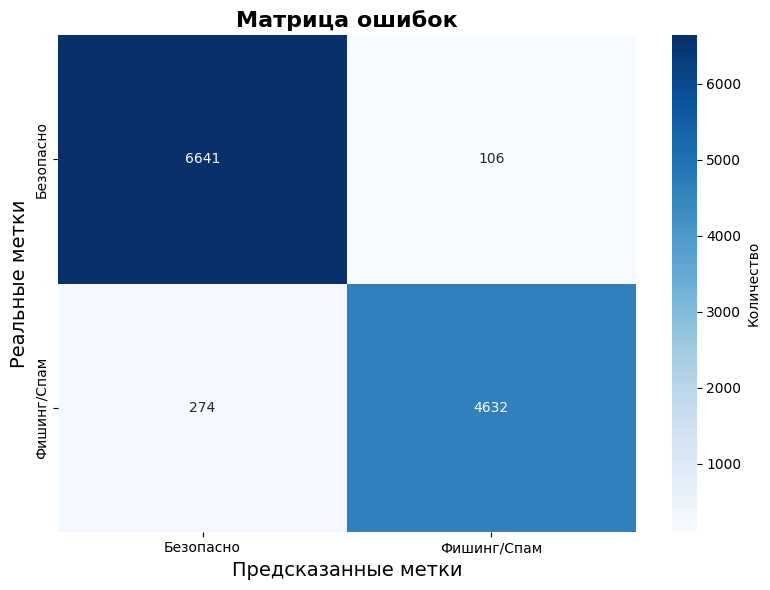


Детальный отчёт классификации:
              precision    recall  f1-score   support

   Безопасно       0.96      0.98      0.97      6747
 Фишинг/Спам       0.98      0.94      0.96      4906

    accuracy                           0.97     11653
   macro avg       0.97      0.96      0.97     11653
weighted avg       0.97      0.97      0.97     11653


Анализ ошибок:
  True Negative (TN): 6641 - правильно распознанные безопасные сообщения
  False Positive (FP): 106 - безопасные, ошибочно помеченные как фишинг
  False Negative (FN): 274 - фишинг, пропущенный фильтром
  True Positive (TP): 4632 - правильно распознанный фишинг
 Модель СЛИШКОМ МЯГКАЯ: пропускает много фишинга.


In [19]:
def plot_confusion_matrix(y_true, y_pred, labels=None):
    """Строит и отображает матрицу ошибок."""
    cm = confusion_matrix(y_true, y_pred)
    if labels is None:
        labels = ["Безопасно", "Фишинг/Спам"] if num_labels == 2 else [str(i) for i in range(num_labels)]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels,
                cbar_kws={"label": "Количество"})
    plt.title("Матрица ошибок", fontsize=16, fontweight="bold")
    plt.ylabel("Реальные метки", fontsize=14)
    plt.xlabel("Предсказанные метки", fontsize=14)
    plt.tight_layout()
    plt.show()
    return cm

print("\nПостроение матрицы ошибок...")
cm = plot_confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel() if num_labels == 2 else (None, None, None, None)

# Вывод подробных метрик
print("\nДетальный отчёт классификации:")
print(classification_report(y_true, y_pred, target_names=["Безопасно", "Фишинг/Спам"] if num_labels == 2 else None))

if num_labels == 2:
    print("\nАнализ ошибок:")
    print(f"  True Negative (TN): {tn} - правильно распознанные безопасные сообщения")
    print(f"  False Positive (FP): {fp} - безопасные, ошибочно помеченные как фишинг")
    print(f"  False Negative (FN): {fn} - фишинг, пропущенный фильтром")
    print(f"  True Positive (TP): {tp} - правильно распознанный фишинг")

    # Интерпретация
    if fp > fn:
        print(" Модель СЛИШКОМ АГРЕССИВНА: много ложных срабатываний.")
    elif fn > fp:
        print(" Модель СЛИШКОМ МЯГКАЯ: пропускает много фишинга.")
    else:
        print(" Модель ХОРОШО СБАЛАНСИРОВАНА.")



Построение ROC-кривой...


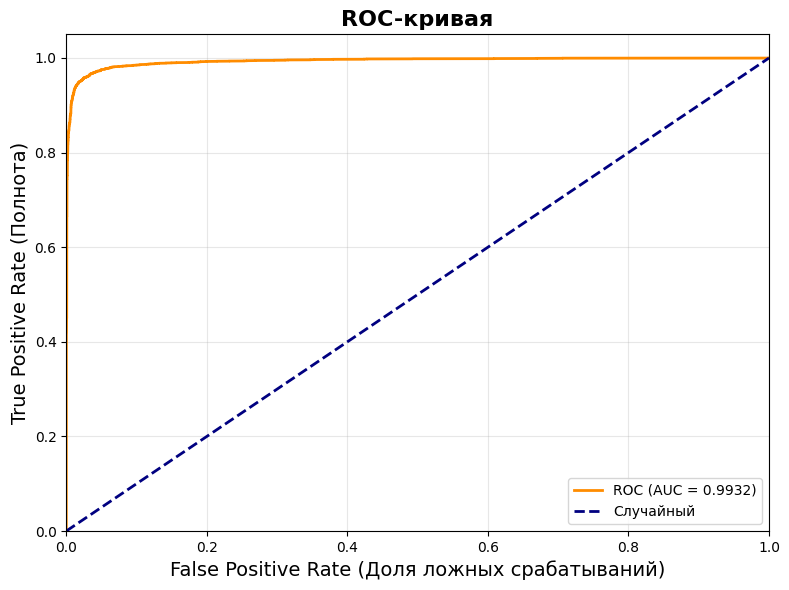

AUC = 0.9932

АНАЛИЗ ОШИБОК

Всего ошибок: 380 (3.3%)
  Ложные срабатывания (FP): 106
  Пропуски (FN): 274

Примеры ложных срабатываний (безопасное → фишинг):
  1. 
    <!doctypehtml><html lang=nl><script src=/gdpr/gdprscript.js?buildTime=1613524086&hasRemindMe=tr...
  2. 
    cishoops.ca/cis2011/index.php
    ...
  3. 
    https://www.slobodenpecat.mk/
    ...
  4. 
    https://secure-lloyd-payee.net.cutestat.com/
    ...
  5. 
    Dear Sir,Salam Alaikkum.Pride and Pleasure meeting you today at the Tea Shop.We are pleased to ...

Примеры пропусков (фишинг → безопасное):
  1. 
    services.runescape.co.cm/m=news/news.ws?article=540
    ...
  2. 
    hisensese.com/front/hitech.document.htm/
    ...
  3. 
    <body>ÿì�ër#Ç•ç?�#ü5lïvK@î Äöx$�í]i¬�4Ú‹Çê�„ dw«C´Ï° 6b_h_aÿ“—Ê,¼´¤ÞËn•×sNž{&*ÿÏÿ...
  4. 
    Money i have won wining number 946 wot do i do next
    ...
  5. 
    <!doctypehtml PUBLIC "-//W3C//DTD HTML 4.01 Transitional//EN"><meta content=text/html;charset=u...

РАБОТА З

In [20]:

# ----------------------------- ROC-кривая (для бинарной классификации) -----
def plot_roc_curve(y_true, y_scores):
    """Строит ROC-кривую и вычисляет AUC."""
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Случайный")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate (Доля ложных срабатываний)", fontsize=14)
    plt.ylabel("True Positive Rate (Полнота)", fontsize=14)
    plt.title("ROC-кривая", fontsize=16, fontweight="bold")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return roc_auc

if num_labels == 2 and y_scores is not None:
    print("\nПостроение ROC-кривой...")
    roc_auc = plot_roc_curve(y_true, y_scores)
    print(f"AUC = {roc_auc:.4f}")

# ----------------------------- Анализ ошибок (примеры) ----------------------
def analyze_errors(texts, y_true, y_pred, num_examples=5):
    """Выводит примеры ошибочных классификаций."""
    misclassified = np.where(y_true != y_pred)[0]
    if len(misclassified) == 0:
        print("\nОшибок нет! Модель идеальна.")
        return

    print(f"\nВсего ошибок: {len(misclassified)} ({len(misclassified)/len(y_true)*100:.1f}%)")

    fp_idx = misclassified[y_pred[misclassified] == 1]
    fn_idx = misclassified[y_pred[misclassified] == 0]

    print(f"  Ложные срабатывания (FP): {len(fp_idx)}")
    print(f"  Пропуски (FN): {len(fn_idx)}")

    if len(fp_idx) > 0:
        print("\nПримеры ложных срабатываний (безопасное → фишинг):")
        for i, idx in enumerate(fp_idx[:num_examples]):
            print(f"  {i+1}. {texts.iloc[idx][:100]}...")

    if len(fn_idx) > 0:
        print("\nПримеры пропусков (фишинг → безопасное):")
        for i, idx in enumerate(fn_idx[:num_examples]):
            print(f"  {i+1}. {texts.iloc[idx][:100]}...")

print("\n" + "=" * 60)
print("АНАЛИЗ ОШИБОК")
print("=" * 60)
analyze_errors(test_df["message"], y_true, y_pred)

print("\n" + "=" * 60)
print("РАБОТА ЗАВЕРШЕНА")
print("=" * 60)

### Примерчики

In [23]:
real_df = load_json_dataset("real_emails.json")

print(f"\nREAL EMAILS: {len(real_df)}")
print(real_df.head())
real_df["message"] = real_df["message"].apply(preprocess_email)
real_dataset = Dataset.from_pandas(real_df[["message", "label"]])
tokenized_real = real_dataset.map(tokenize_function, batched=True)
tokenized_real = tokenized_real.remove_columns(["message"])

real_emails.json: 7 samples

REAL EMAILS: 7
                                             message  label
0  Body: Dear Customer, Thank you for shopping wi...      0
1  ---------- Forwarded message --------- From: F...      0
2  Здравствуйте! У меня возник вопрос по регламен...      0
3  Здравствуйте! Высылаю выполненные лабораторные...      0
4  Notification settings <https://accounts.google...      0


Map: 100%|██████████| 7/7 [00:00<00:00, 20.61 examples/s]


In [25]:
real_results = trainer.predict(tokenized_real)
real_preds = np.argmax(real_results.predictions, axis=1)

probs = torch.softmax(torch.from_numpy(real_results.predictions), dim=1)
real_probs = probs[:, 1].numpy()

y_true_real = real_results.label_ids

100%|██████████| 1/1 [00:00<00:00, 332.64it/s]


In [26]:
for i in range(len(real_df)):
    print("\n" + "-" * 50)
    print(f"TEXT:\n{real_df.iloc[i]['message'][:300]}...")
    print(f"TRUE: {y_true_real[i]}")
    print(f"PRED: {real_preds[i]}")
    print(f"PROB_SPAM: {real_probs[i]:.4f}")


--------------------------------------------------
TEXT:

    Body: Dear Customer, Thank you for shopping with us! Your order #123456 has been successfully processed. Items: - Wireless Mouse (x1) – $25.99 - USB-C Cable (x2) – $15.98 Total: $41.97 Estimated delivery: March 20-25. You can track your order here: https://www.onlinestore.com/track/123456 Since...
TRUE: 0
PRED: 0
PROB_SPAM: 0.0081

--------------------------------------------------
TEXT:

    ---------- Forwarded message --------- From: FT-Авито <careerday@futuretoday.company> Date: Tue, Nov 11, 2025 at 5:19 PM Subject: Набор айтишников на стажировку в Авито To: <chernikova.vasilisa42@gmail.com> 4 направления и классные условия ͏‌͏͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏‌ ͏...
TRUE: 0
PRED: 0
PROB_SPAM: 0.0001

--------------------------------------------------
TEXT:

    Здравствуйте! У меня возник вопрос по регламенту проведения прокторинга. В инструкции сказано, что нельзя открывать дополнительные вкладки браузе